# nb05 · 老化与容量衰减（Degradation）

本篇目标：

1. 开启 **SEI 生长 + 析锂（lithium plating）** 退化子模型，跑多循环，绘制**容量保持率 vs 循环数**。
2. 对比「仅 SEI」与「SEI + 析锂」两种退化机制。
3. 提取老化指标：锂库存损失（LLI）、SEI 容量损失。
4. 展示**温度对老化速率的加速**作用（结合 nb04 的热模型）。

退化子模型通过 `options` 开启，例如 `{"SEI": "solvent-diffusion limited", "lithium plating": "partially reversible"}`。
本篇用 `OKane2022` 参数集（专为退化研究标定）与 SPM（最快），循环数取百级以便快速演示；
真实寿命评估通常需数百~数千循环。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pybamm

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

# 单个充放循环：恒流放电 -> CCCV 充电
CYCLE = (
    "Discharge at 1C until 2.5 V",
    "Charge at 1C until 4.2 V",
    "Hold at 4.2 V until C/20",
)
print("PyBaMM 版本:", pybamm.__version__)

PyBaMM 版本: 26.6.1.1


## 1. SEI + 析锂：容量保持率 vs 循环数

用 `summary_variables` 提取每个循环结束时的容量、LLI 等汇总指标。

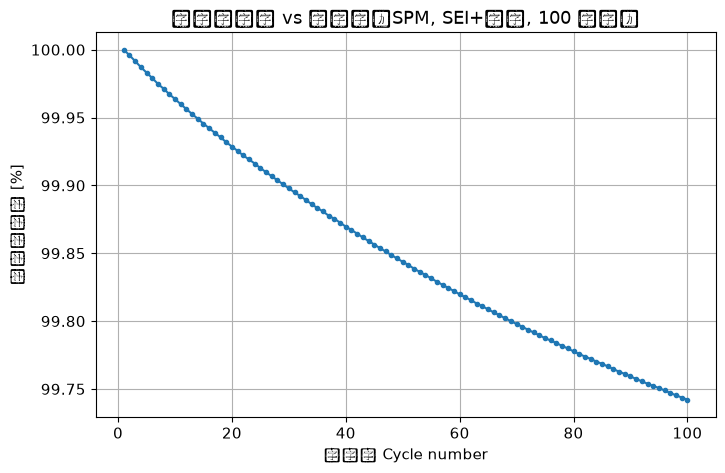

第 100 循环容量保持率: 99.742 %
校验通过：容量保持率随循环数单调下降。


In [2]:
N = 100
model = pybamm.lithium_ion.SPM(
    options={"SEI": "solvent-diffusion limited", "lithium plating": "partially reversible"}
)
sim = pybamm.Simulation(model, parameter_values=pybamm.ParameterValues("OKane2022"),
                        experiment=pybamm.Experiment([CYCLE] * N))
sol = sim.solve()

# 注：summary_variables[key] 可能返回 Python list，统一用 np.asarray 便于做数组运算
sv = sol.summary_variables
cycles = np.asarray(sv["Cycle number"])
cap = np.asarray(sv["Capacity [A.h]"])
retention = cap / cap[0] * 100

plt.plot(cycles, retention, "o-", ms=3)
plt.xlabel("循环数 Cycle number")
plt.ylabel("容量保持率 [%]")
plt.title(f"容量保持率 vs 循环数（SPM, SEI+析锂, {N} 循环）")
plt.show()

print(f"第 {N} 循环容量保持率: {retention[-1]:.3f} %")
assert retention[-1] < retention[0], "预期：容量保持率随循环数下降"
assert np.all(np.diff(retention) <= 1e-6), "预期：容量保持率单调不增"
print("校验通过：容量保持率随循环数单调下降。")

## 2. 老化指标分解：LLI 与 SEI 容量损失

锂库存损失（Loss of Lithium Inventory）与 SEI 消耗的容量随循环增长，是容量衰减的主因。

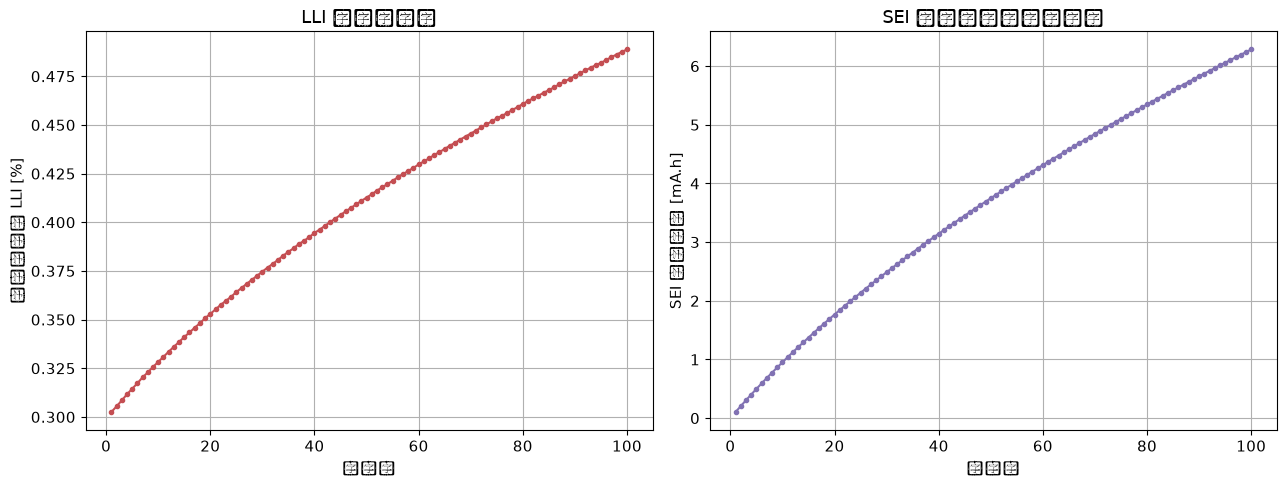

In [3]:
lli = np.asarray(sv["Loss of lithium inventory [%]"])
sei_loss = np.asarray(sv["Loss of capacity to negative SEI [A.h]"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(cycles, lli, "o-", ms=3, color="#C44E52")
ax1.set_xlabel("循环数"); ax1.set_ylabel("锂库存损失 LLI [%]"); ax1.set_title("LLI 随循环增长")
ax2.plot(cycles, sei_loss * 1000, "o-", ms=3, color="#8172B3")
ax2.set_xlabel("循环数"); ax2.set_ylabel("SEI 容量损失 [mA.h]"); ax2.set_title("SEI 容量损失随循环增长")
plt.tight_layout(); plt.show()

## 3. 退化机制对比：仅 SEI vs SEI + 析锂

加入析锂机制后，额外的锂损失会加速容量衰减。

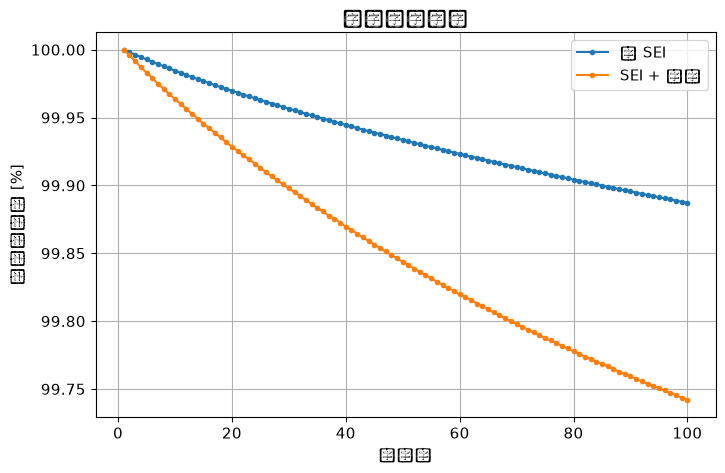

In [4]:
mechanisms = {
    "仅 SEI": {"SEI": "solvent-diffusion limited"},
    "SEI + 析锂": {"SEI": "solvent-diffusion limited", "lithium plating": "partially reversible"},
}
N2 = 100
for label, opts in mechanisms.items():
    m = pybamm.lithium_ion.SPM(options=opts)
    s = pybamm.Simulation(m, parameter_values=pybamm.ParameterValues("OKane2022"),
                          experiment=pybamm.Experiment([CYCLE] * N2)).solve()
    sv2 = s.summary_variables
    cap2 = np.asarray(sv2["Capacity [A.h]"])
    ret = cap2 / cap2[0] * 100
    plt.plot(np.asarray(sv2["Cycle number"]), ret, "o-", ms=3, label=label)
plt.xlabel("循环数"); plt.ylabel("容量保持率 [%]")
plt.title("退化机制对比"); plt.legend(); plt.show()

## 4. 温度对老化的加速作用

SEI 生长是热激活过程，**温度越高、老化越快**。这里在集总热模型下对比 25 °C 与 40 °C。

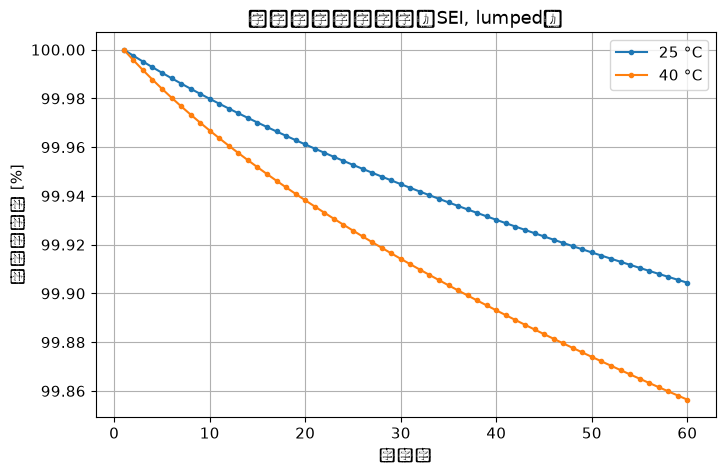

末循环容量保持率 [%]: {25: np.float64(99.904), 40: np.float64(99.856)}
校验通过：40 °C 老化快于 25 °C。


In [5]:
N3 = 60
final_ret = {}
for T_amb_C in [25, 40]:
    param = pybamm.ParameterValues("OKane2022")
    param["Ambient temperature [K]"] = 273.15 + T_amb_C
    param["Initial temperature [K]"] = 273.15 + T_amb_C
    m = pybamm.lithium_ion.SPM(options={"SEI": "solvent-diffusion limited", "thermal": "lumped"})
    s = pybamm.Simulation(m, parameter_values=param,
                          experiment=pybamm.Experiment([CYCLE] * N3)).solve()
    sv3 = s.summary_variables
    cap3 = np.asarray(sv3["Capacity [A.h]"])
    ret = cap3 / cap3[0] * 100
    final_ret[T_amb_C] = ret[-1]
    plt.plot(np.asarray(sv3["Cycle number"]), ret, "o-", ms=3, label=f"{T_amb_C} °C")
plt.xlabel("循环数"); plt.ylabel("容量保持率 [%]")
plt.title("温度对老化的加速（SEI, lumped）"); plt.legend(); plt.show()

print("末循环容量保持率 [%]:", {k: round(v, 3) for k, v in final_ret.items()})
assert final_ret[40] < final_ret[25], "预期：温度越高老化越快"
print("校验通过：40 °C 老化快于 25 °C。")

## 小结

- 退化通过 `options`（`SEI` / `lithium plating` / `particle mechanics` 等）开启，跑多循环 `Experiment`。
- 用 `solution.summary_variables` 提取每循环的容量、LLI、SEI 损失等老化指标。
- 析锂会在 SEI 之上**进一步加速**容量衰减；**温度升高**显著加速老化。
- 扩展到上百~上千循环只需增大循环次数 `N`（DFN 更准但更慢；演示用 SPM 即可）。
- 下一篇 `nb06` 进入**参数辨识**。